# EDA del corpus ChefGPT_Dataset_Random_Sample

Este cuaderno explora la estructura, calidad y variabilidad del corpus gastronómico antes de aplicar RAG.

La idea es detectar problemas de normalización, outliers de longitud, sesgos de autores y patrones que puedan afectar el chunking, los embeddings y la recuperación.

In [49]:
from pathlib import Path
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/xabierlosa/ProyectoPLN.git"
ROOT = Path("/content/ProyectoPLN")

if not (ROOT / ".git").exists():
    if ROOT.exists():
        shutil.rmtree(ROOT)
    subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)

sys.path.insert(0, str(ROOT))
print(f"Repositorio listo en {ROOT}")

Repositorio listo en /content/ProyectoPLN


**Nota:** Clona el repositorio y añade `ROOT` a `sys.path`.

## Objetivos del análisis

- Entender el esquema real del JSON y la calidad de cada campo.
- Medir longitudes de títulos, instrucciones e ingredientes para anticipar problemas de contexto.
- Analizar el vocabulario culinario y la normalización de ingredientes.
- Revisar distribución de tiempos, porciones, autores y número de ingredientes.
- Identificar implicaciones prácticas para el pipeline RAG.

El siguiente código arga `ChefGPT_Dataset_Random_Sample.json` en `df`. Verifica tamaño, encoding y estructura antes de seguir; `df.head(3)` ayuda a validar el esquema.

In [50]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = ROOT / "ChefGPT_Dataset_Random_Sample.json"

with DATA_PATH.open(encoding="utf-8") as f:
    recipes_raw = json.load(f)

df = pd.DataFrame(recipes_raw)
df.head(3)

,titulo,ingredientes,instrucciones,tiempo_total,porciones,autor,n_ingredientes
0,"Empanadillas de atún, tomate y huevo: un clási...","[300g Atún en conserva, 2 Huevo, Salsa de toma...",comenzamos cociendo los huevos en agua con sal...,15 minutos,4,Pakus,4
1,"Receta de caballa con salsa de tomate, la rece...","[2 Caballa, 400ml Salsa de tomate, 2 Patata, A...","en una cazuela baja, freímos ligeramente los l...",30 minutos,2,Pakus,6
2,Las naranjas están en su mejor momento: las me...,"[1 Pollo entero, 3 Naranja, 2 Patata, Finas Hi...","limpiamos el pollo de plumones, vigilad en esp...",90 minutos,4,Pakus,7


## Vista general del corpus

Antes de cualquier análisis semántico conviene revisar el esquema, los tipos, el tamaño y las primeras filas para comprobar que el JSON es homogéneo.

In [51]:
print(f"Recetas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")

schema = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values,
})
display(schema)
display(df.sample(min(5, len(df)), random_state=42))

hashable_df = df.copy()
for column in hashable_df.columns:
    if hashable_df[column].map(lambda value: isinstance(value, list)).any():
        hashable_df[column] = hashable_df[column].apply(lambda value: tuple(value) if isinstance(value, list) else value)

print("Duplicados exactos:", hashable_df.duplicated().sum())
display(df.isna().sum().to_frame("nulos"))

Recetas: 1,500
Columnas: 7


,columna,tipo
0,titulo,object
1,ingredientes,object
2,instrucciones,object
3,tiempo_total,object
4,porciones,object
5,autor,object
6,n_ingredientes,int64


,titulo,ingredientes,instrucciones,tiempo_total,porciones,autor,n_ingredientes
1116,Ensalada de brotes de espinacas y fresas: rece...,"[150g Brotes de espinacas, 25count Fresa, 80g ...",comenzaremos preparando el aliño para ello en ...,20 minutos,4,Esther Clemente,9
1368,Queso Camembert relleno de frutos secos: recet...,"[1count Queso Camembert, 50g Queso mascarpone,...",comenzamos poniendo las pasas en un pequeño cu...,20 minutos,1,Carmen Tía Alia,4
422,Financiers con frambuesas en taza al microonda...,"[30g Mantequilla, 33g Azúcar glasé, 24g Harina...","mezclamos el azúcar glas, la harina, la almend...",12 minutos,2,Unodedos,7
413,"Receta de tortilla de espinacas, la opción más...","[3count Huevo, 75g Brotes de espinacas, 1 Ajo ...",saltear las espinacas a fuego muy fuerte duran...,15 minutos,2,Mesa Cero Chefs y Jaime de las Heras,7
451,"Receta de garbanzos con langostinos, un potaje...","[400g Garbanzos, 1count Cebolla blanca, 2count...","si se parte de langostinos sin pelar, hay que ...",60 minutos,4,Liliana Fuchs,17


Duplicados exactos: 0


,nulos
titulo,0
ingredientes,0
instrucciones,0
tiempo_total,0
porciones,0
autor,0
n_ingredientes,0


No hay recetas duplicadas, ni campos vacios a lo largo de todo el dataset.

## Normalización y variables derivadas

El corpus mezcla texto libre con campos semiestructurados. Para entenderlo mejor, extraemos variables numéricas y limpiamos ingredientes para estudiar el vocabulario culinario.

In [52]:
quantity_prefix = re.compile(r"^\s*[\d.,/]+(?:\s*[a-záéíóúñ]+)?\s*", re.I)

def parse_minutes(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\d+", str(value))
    return float(match.group()) if match else np.nan

def parse_portions(value):
    numeric = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    if pd.notna(numeric):
        return float(numeric)
    match = re.search(r"\d+", str(value))
    return float(match.group()) if match else np.nan

def normalize_ingredient(text):
    text = str(text).strip().lower()
    text = quantity_prefix.sub("", text)
    text = re.sub(r"\s*\([^)]*\)", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip(" ,.;:-")

df = df.copy()
df["ingredientes_count_real"] = df["ingredientes"].apply(lambda value: len(value) if isinstance(value, list) else np.nan)
df["tiempo_min"] = df["tiempo_total"].apply(parse_minutes)
df["porciones_num"] = df["porciones"].apply(parse_portions)
df["titulo_chars"] = df["titulo"].astype(str).str.len()
df["titulo_words"] = df["titulo"].astype(str).str.split().str.len()
df["instrucciones_chars"] = df["instrucciones"].astype(str).str.len()
df["instrucciones_words"] = df["instrucciones"].astype(str).str.split().str.len()
df["ingrediente_prom_words"] = df["ingredientes"].apply(
    lambda values: np.mean([len(str(item).split()) for item in values]) if isinstance(values, list) and values else np.nan
)
df["ingredientes_norm"] = df["ingredientes"].apply(
    lambda values: [normalize_ingredient(item) for item in values] if isinstance(values, list) else []
)
df["n_ingredientes_coincide"] = df["ingredientes_count_real"] == df["n_ingredientes"]

display(df[["titulo", "tiempo_total", "porciones", "n_ingredientes", "ingredientes_count_real"]].head(5))

,titulo,tiempo_total,porciones,n_ingredientes,ingredientes_count_real
0,"Empanadillas de atún, tomate y huevo: un clási...",15 minutos,4,4,4
1,"Receta de caballa con salsa de tomate, la rece...",30 minutos,2,6,6
2,Las naranjas están en su mejor momento: las me...,90 minutos,4,7,7
3,Rosquillas de San Blas: receta tradicional al ...,50 minutos,15,10,10
4,Tarta de yogur griego y queso fresco desnatado...,70 minutos,8,9,9


## Control de calidad de los datos

Aquí buscamos inconsistencias que pueden afectar al chunking, a la extracción de atributos o a la recuperación semántica.

In [63]:
quality = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "tipo": df.dtypes.astype(str),
})
display(quality)

print("Recetas con n_ingredientes distinto al tamaño real de la lista:", (~df["n_ingredientes_coincide"]).sum())
print("Tiempos no parseables:", df["tiempo_min"].isna().sum())
print("Porciones no numéricas:", df["porciones_num"].isna().sum())

display(df.loc[df["porciones_num"].isna(), ["titulo", "porciones"]].head(10))

,nulos,porcentaje_nulos,tipo
titulo,0,0.0,object
ingredientes,0,0.0,object
instrucciones,0,0.0,object
tiempo_total,0,0.0,object
porciones,0,0.0,object
autor,0,0.0,object
n_ingredientes,0,0.0,int64
ingredientes_count_real,0,0.0,int64
tiempo_min,0,0.0,float64
porciones_num,27,1.8,float64


Recetas con n_ingredientes distinto al tamaño real de la lista: 0
Tiempos no parseables: 0
Porciones no numéricas: 27


,titulo,porciones
106,"Caldo de res, receta del plato mexicano perfec...",
117,Receta de garbanzos con pisto,
317,Torta de San Blas: receta del dulce vasco que ...,
342,"Crema chiboust: qué es, cómo se hace y para qu...",
404,Cómo hacer cereales con chocolate para el desa...,
430,"Cake ultratierno de plátano y avellanas, recet...",
520,"Garam masala: qué es, cómo hacerlo y qué uso d...",
539,"Confitura de higos y nueces especiada, receta ...",
588,"Cómo elaborar pasta choux casera: receta, truc...",
622,"Salsa de Navidad, receta de postre tradicional...",


**Observaciones:** en general el corpus tiene muy buena completitud —las columnas críticas (título, ingredientes, instrucciones, tiempo_total, autor) no muestran nulos y no hay discrepancias entre `n_ingredientes` e `ingredientes_count_real`. Los tiempos se han parseado correctamente (`Tiempos no parseables: 0`). El único punto a revisar son las `porciones`: `porciones_num` tiene 27 valores no numéricos (~1.8%). Después de explorar estos casos, concluimos que se trata en gran medida de salsas y cremas, casos para los cuales este campo no es tan informativo. Tras esa limpieza, los campos numéricos y las variables derivadas estarán listos para indexado y análisis RAG.

## Estadística descriptiva

Estas variables ayudan a estimar el tamaño del contexto que cada receta puede aportar al RAG y a detectar colas largas de instrucciones o recetas con pocos/muchos ingredientes.

,count,mean,std,min,25%,50%,75%,max
tiempo_min,1500.0,45.05,58.50,0.0,20.00,35.00,55.00,1210.00
porciones_num,1473.0,5.68,6.36,0.0,2.00,4.00,6.00,60.00
ingredientes_count_real,1500.0,8.96,3.43,2.0,6.00,9.00,11.00,22.00
n_ingredientes,1500.0,8.96,3.43,2.0,6.00,9.00,11.00,22.00
titulo_chars,1500.0,77.43,21.52,22.0,63.00,77.00,92.00,139.00
titulo_words,1500.0,12.91,3.87,3.0,10.00,13.00,16.00,25.00
instrucciones_chars,1500.0,1150.29,478.65,109.0,830.75,1088.00,1404.50,5443.00
instrucciones_words,1500.0,198.53,82.62,19.0,143.00,188.00,242.25,966.00
ingrediente_prom_words,1500.0,2.85,0.48,1.5,2.57,2.82,3.10,6.12


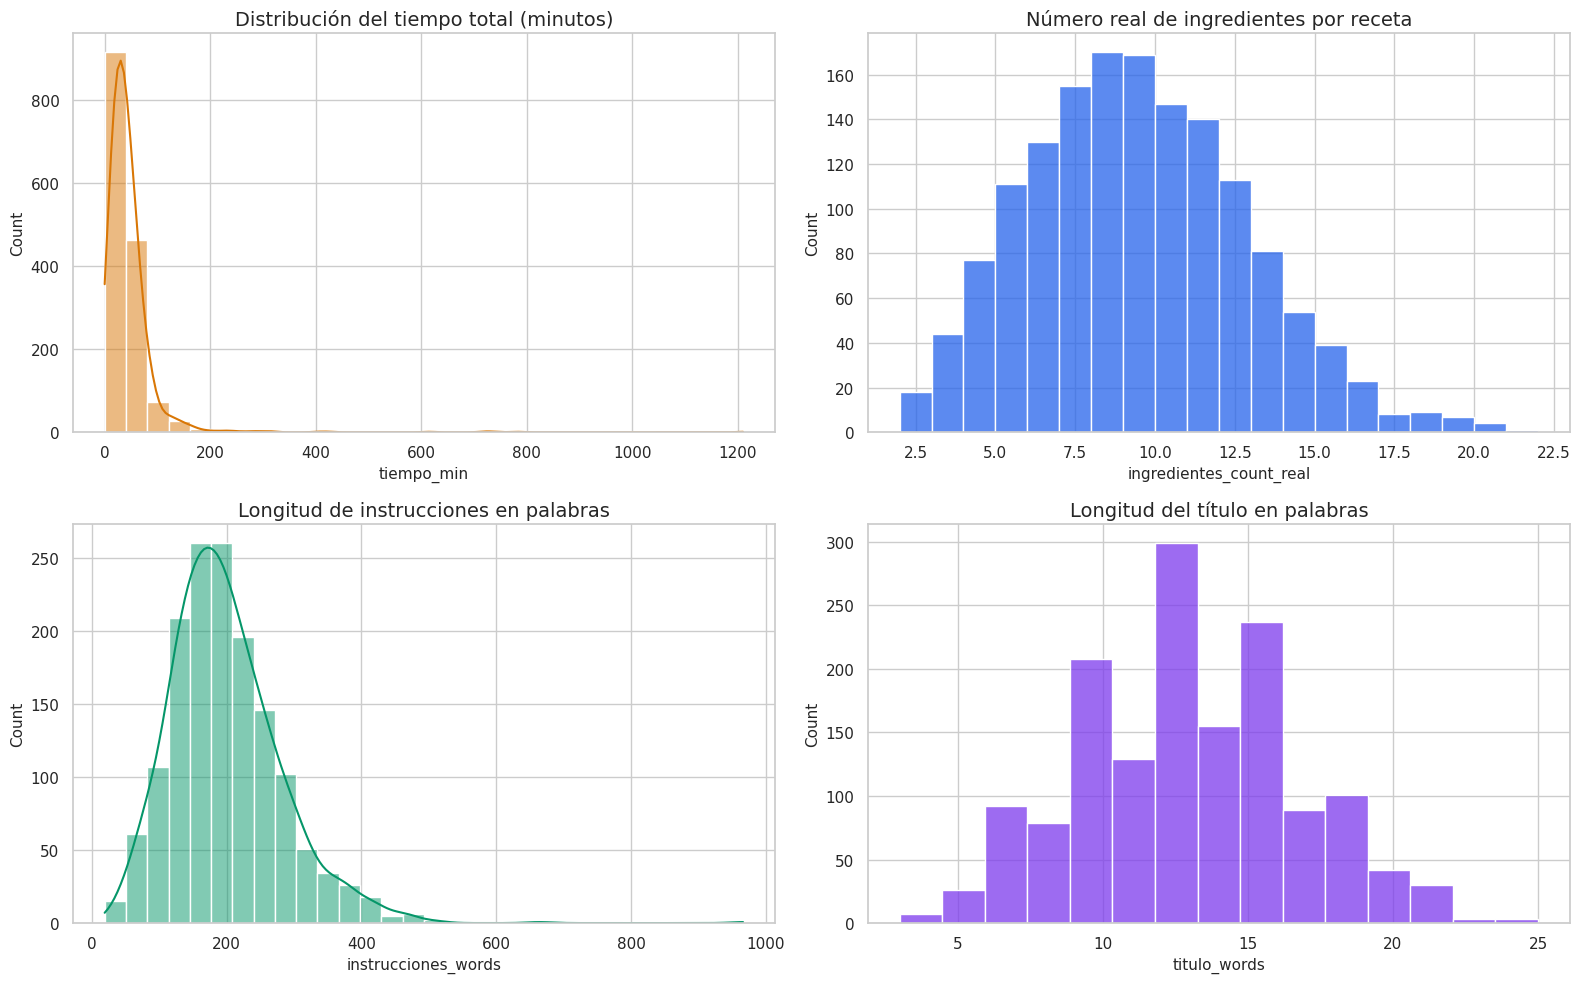

In [54]:
numeric_cols = [
    "tiempo_min",
    "porciones_num",
    "ingredientes_count_real",
    "n_ingredientes",
    "titulo_chars",
    "titulo_words",
    "instrucciones_chars",
    "instrucciones_words",
    "ingrediente_prom_words",
]
display(df[numeric_cols].describe().T.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df["tiempo_min"], bins=30, kde=True, ax=axes[0, 0], color="#d97706")
axes[0, 0].set_title("Distribución del tiempo total (minutos)")

sns.histplot(df["ingredientes_count_real"], bins=20, ax=axes[0, 1], color="#2563eb")
axes[0, 1].set_title("Número real de ingredientes por receta")

sns.histplot(df["instrucciones_words"], bins=30, kde=True, ax=axes[1, 0], color="#059669")
axes[1, 0].set_title("Longitud de instrucciones en palabras")

sns.histplot(df["titulo_words"], bins=15, ax=axes[1, 1], color="#7c3aed")
axes[1, 1].set_title("Longitud del título en palabras")

plt.tight_layout()

**Observaciones**

- **`tiempo_min`**: concentración en recetas de duración baja-media y una cola larga de recetas mucho más lentas; usar percentiles (p.ej. 90–95º) para definir umbrales operativos y filtros.
- **`ingredientes_count_real`**: la mayoría de recetas tienen pocos a moderados ingredientes; las recetas con muchos ingredientes incrementan el coste semántico y la granularidad requerida en el índice.
- **`instrucciones_words`**: fuerte asimetría derecha — muchas instrucciones cortas/medias y algunas extremadamente largas; estas requieren chunking por pasos/frases para evitar pérdida de contexto en RAG.
- **`titulo_words`**: títulos generalmente cortos y útiles para búsquedas rápidas; pocos títulos largos que podrían truncarse en vistas compactas.
- **Robustez de metadatos**: `tiempo_min` es una señal fiable para filtros temporales; `porciones_num` no es fiable hasta normalizar sus casos no numéricos.
- **Implicación práctica**: definir percentiles para outliers, normalizar ingredientes y porciones, y aplicar chunking inteligente en instrucciones largas mejorará eficiencia de indexado y calidad de recuperación.

## Ingredientes: normalización y frecuencias

El campo `ingredientes` es especialmente importante para RAG porque determina la cobertura semántica del corpus. Aquí extraemos frecuencias de ingredientes normalizados y revisamos la consistencia del formato.

/tmp/ipykernel_1000/4188722551.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ingredients.values, y=top_ingredients.index, ax=ax, palette="magma")


,con_prefijo_numerico_%,con_token_count_%,con_parentesis_%,sin_prefijo_numerico_%
0,69.38,17.1,0.65,30.62


,ingredientes_con_count
3,3count Huevo
3,1count Ralladura de limón
3,2count Clara de huevo
4,4count Huevo
6,2count Huevos
9,1count Hojaldre
9,5count Manzana
9,6count Laurel
9,1count Ralladura de limón
9,1count Huevo


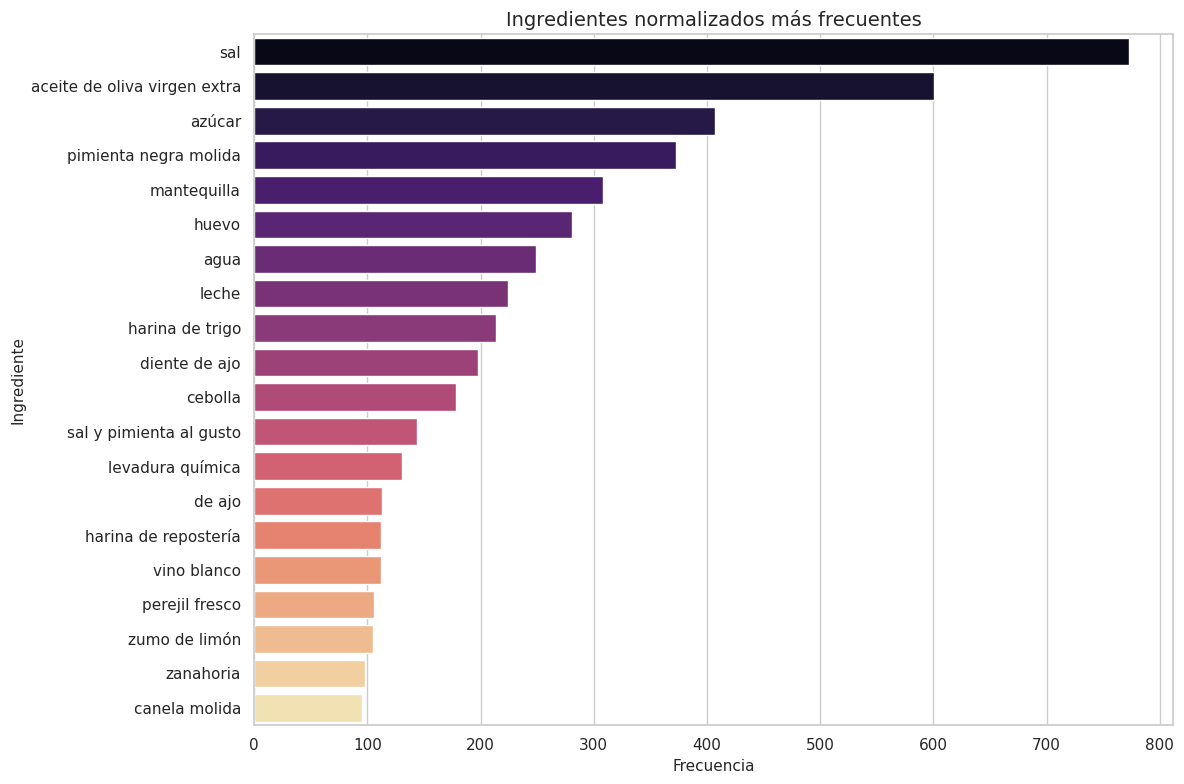

In [55]:
ingredient_rows = (
    df[["titulo", "ingredientes"]]
    .explode("ingredientes")
    .dropna(subset=["ingredientes"])
    .rename(columns={"ingredientes": "ingrediente_bruto"})
)
ingredient_rows["ingrediente_norm"] = ingredient_rows["ingrediente_bruto"].map(normalize_ingredient)
ingredient_rows = ingredient_rows[ingredient_rows["ingrediente_norm"] != ""]

top_ingredients = ingredient_rows["ingrediente_norm"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=top_ingredients.values, y=top_ingredients.index, ax=ax, palette="magma")
ax.set_title("Ingredientes normalizados más frecuentes")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Ingrediente")
plt.tight_layout()

raw_ingredients = df.explode("ingredientes")["ingredientes"].dropna().astype(str)
issue_table = pd.DataFrame({
    "con_prefijo_numerico_%": [raw_ingredients.str.match(r"^\s*[\d.,/]+", na=False).mean() * 100],
    "con_token_count_%": [raw_ingredients.str.contains("count", case=False, na=False).mean() * 100],
    "con_parentesis_%": [raw_ingredients.str.contains(r"\(", regex=True, na=False).mean() * 100],
    "sin_prefijo_numerico_%": [(~raw_ingredients.str.match(r"^\s*[\d.,/]+", na=False)).mean() * 100],
})
display(issue_table.round(2))
display(raw_ingredients[raw_ingredients.str.contains("count", case=False, na=False)].head(15).to_frame("ingredientes_con_count"))

**Observaciones:**

- El campo `ingredientes` es altamente heterogéneo: aparecen prefijos numéricos, unidades, anotaciones entre paréntesis y tokens no estándar (p. ej. "count"). Este ruido inflará el vocabulario y degradará la calidad de embeddings si no se normaliza.
- Muchas entradas combinan cantidad/unidad/ingrediente en la misma cadena; extraer `cantidad` y `unidad` como columnas separadas y canonizar el `ingrediente` reduce ambigüedad y mejora búsquedas por ingrediente.
- El `issue_table` muestra una proporción no desdeñable de ingredientes con prefijos numéricos y paréntesis; priorizar la eliminación/normalización de estos elementos antes de construir embeddings.
- Normalizar a formas canónicas (minúsculas, eliminación de paréntesis, mapeo de sinónimos como "aceite de oliva" → "aceite") y estandarizar unidades (g, ml, taza) disminuirá la dimensionalidad y mejorará la precisión de recuperación semántica.
- Impacto: una limpieza cuidadosa de `ingredientes` aumentará la densidad y coherencia del índice FAISS, reducirá falsos negativos en búsquedas por ingrediente y mejorará la calidad de agrupamientos y clusters semánticos.

## Autores, cobertura y diversidad

Los autores ayudan a entender sesgos del corpus: hay firmas muy repetidas, autores corporativos y recetas con atribuciones mixtas. Esto puede ser útil para análisis de procedencia o para filtrar ruido antes del RAG.

,recetas
autor,
Liliana Fuchs,271
Pakus,240
Carmen Tía Alia,226
Esther Clemente,146
Maria Jose,139
Mesa Cero Chefs y Jaime de las Heras,89
Inés Vazquez Noya,76
Unodedos,55
Marina Blanco,47


Autores únicos: 26
Concentración de las 10 firmas más frecuentes: 88.47%
Media de palabras en los títulos: 12.91
Mediana de palabras en las instrucciones: 188.00


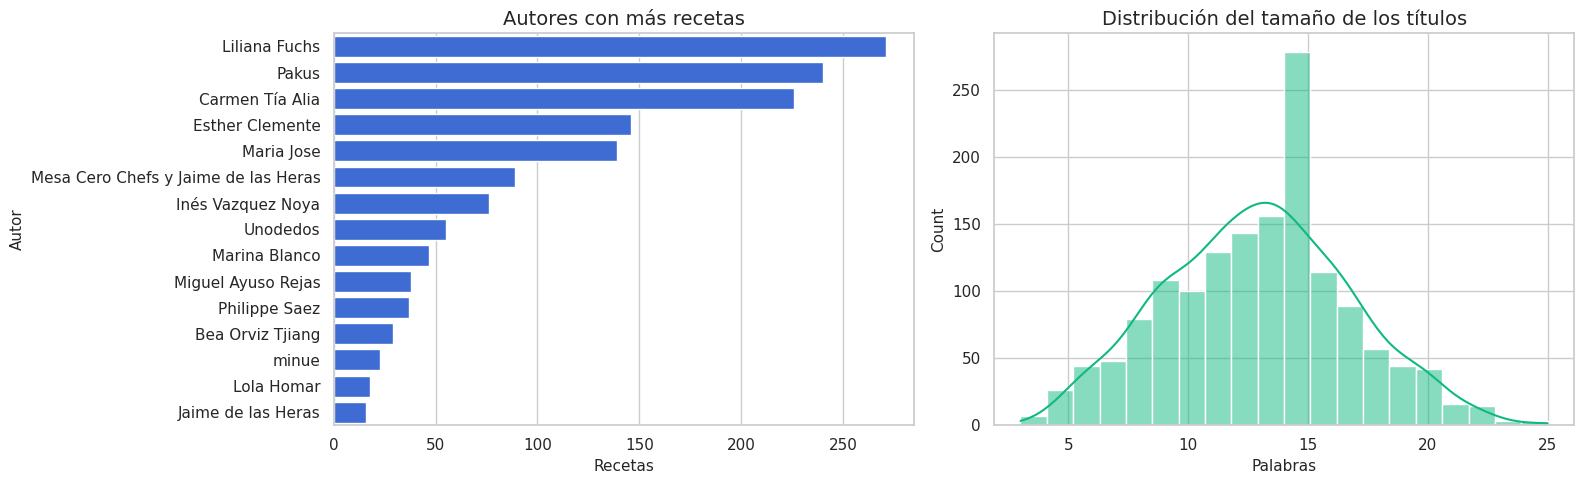

In [56]:
author_counts = df["autor"].fillna("Desconocido").value_counts()
display(author_counts.head(15).to_frame("recetas"))

top_10_share = author_counts.head(10).sum() / len(df) * 100
print(f"Autores únicos: {df['autor'].nunique(dropna=True):,}")
print(f"Concentración de las 10 firmas más frecuentes: {top_10_share:.2f}%")
print(f"Media de palabras en los títulos: {df['titulo_words'].mean():.2f}")
print(f"Mediana de palabras en las instrucciones: {df['instrucciones_words'].median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=author_counts.head(15).values, y=author_counts.head(15).index, ax=axes[0], color="#2563eb")
axes[0].set_title("Autores con más recetas")
axes[0].set_xlabel("Recetas")
axes[0].set_ylabel("Autor")

sns.histplot(df["titulo_words"], bins=20, kde=True, ax=axes[1], color="#10b981")
axes[1].set_title("Distribución del tamaño de los títulos")
axes[1].set_xlabel("Palabras")

plt.tight_layout()

**Observaciones:**

- **Concentración de firmas:** unas pocas firmas concentran una parte importante del corpus; esto puede introducir sesgos estilísticos y terminológicos que conviene tener en cuenta al muestrear para evaluación o entrenamiento.
- **Diversidad temática:** si bien hay variedad, la prevalencia de autores dominantes sugiere que ciertas recetas/estilos podrían estar sobrerrepresentados (p. ej. técnicas o vocabulario recurrente).
- **Implicaciones prácticas:** usar `autor` como metadato para estratificar muestreos o para crear filtros en consultas RAG reducirá riesgo de respuestas sesgadas.

## Relaciones entre variables

La relación entre tiempo, número de ingredientes y longitud de las instrucciones permite detectar recetas costosas de recuperar y potenciales outliers que podrían ocupar demasiado contexto.

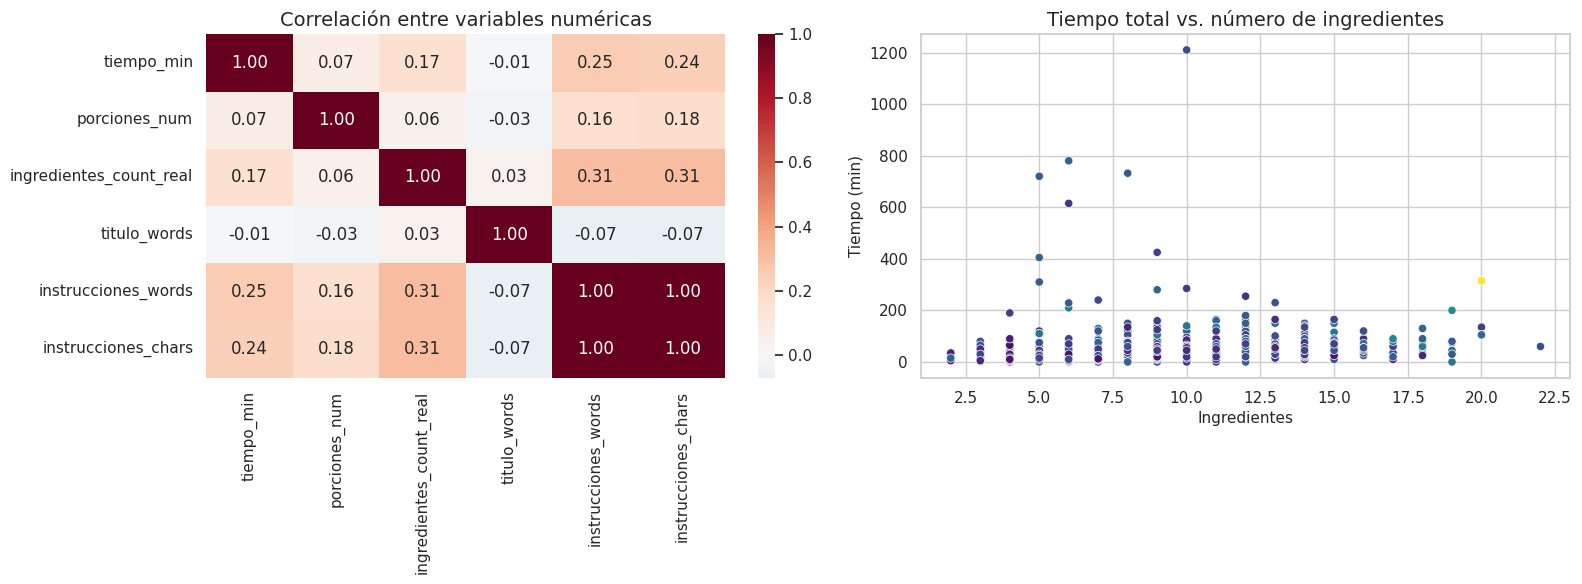

In [57]:
corr_cols = [
    "tiempo_min",
    "porciones_num",
    "ingredientes_count_real",
    "titulo_words",
    "instrucciones_words",
    "instrucciones_chars",
]
corr = df[corr_cols].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Correlación entre variables numéricas")

sns.scatterplot(
    data=df,
    x="ingredientes_count_real",
    y="tiempo_min",
    hue="instrucciones_words",
    palette="viridis",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Tiempo total vs. número de ingredientes")
axes[1].set_xlabel("Ingredientes")
axes[1].set_ylabel("Tiempo (min)")

plt.tight_layout()

In [65]:
longest_instructions = df.nlargest(10, "instrucciones_words")[
    ["titulo", "autor", "tiempo_total", "porciones", "ingredientes_count_real", "instrucciones_words"]
]
fastest_recipes = df.nsmallest(10, "tiempo_min")[
    ["titulo", "autor", "tiempo_total", "porciones", "ingredientes_count_real", "instrucciones_words"]
]

display(longest_instructions)
display(fastest_recipes)

,titulo,autor,tiempo_total,porciones,ingredientes_count_real,instrucciones_words
1299,Croquembouche: receta paso a paso para lograr ...,Esther Clemente,315 minutos,15,20,966
6,La receta de croquetas de Francis Paniego: una...,Pakus,75 minutos,6,9,664
982,Tarta mousse de queso crema con interior de fr...,Esther Clemente,65 minutos,6,11,511
577,"Pastel de zanahoria sin gluten, receta para ce...",Carmen Tía Alia,65 minutos,4,15,504
408,Pollo con nata y champiñones: un guiso fácil y...,Miguel Ayuso,85 minutos,2,14,478
515,"Tarta Fraisier, frescura y textura exquisita e...",Esther Clemente,80 minutos,8,18,472
907,"Capón relleno al horno, receta clásica de Navi...",Carmen Tía Alia,200 minutos,8,19,468
67,Cómo hacer dónuts rellenos de mermelada con ma...,Carmen Tía Alia,60 minutos,12,12,466
472,Cómo hacer un buen caldo de pescado a base de ...,Pakus,0 minutos,6,7,466
159,"Bacalao al pil pil, descubre esta receta clási...",Esther Clemente,60 minutos,6,5,465


,titulo,autor,tiempo_total,porciones,ingredientes_count_real,instrucciones_words
41,"Guiso de calamares con chorizo, un plato de cu...",Lola Homar,0 minutos,4,10,120
84,Esta es nuestra receta de ensaladilla rusa clá...,Carmen Tía Alia,0 minutos,4,6,361
92,"Tagliatelle con pesto y espárragos, una receta...",Pakus,0 minutos,4,6,291
183,Champiñones gratinados rellenos con espinacas:...,Philippe Saez,0 minutos,2,8,206
299,"Cómo hacer ñoquis de patata caseros, la mejor ...",Pintxo,0 minutos,4,5,197
352,Pollo asado con cítricos y sirope de arce: rec...,Esther Clemente,0 minutos,4,9,163
354,Pastel de calabacín y queso al horno: una rece...,Miguel Ayuso Rejas,0 minutos,4,10,188
361,"Receta de espaguetis con peperonata, la riquís...",Esther Clemente,0 minutos,4,12,119
366,"Pilotes de Nadal o pelotas de Navidad, una rec...",Carmen Tía Alia,0 minutos,6,10,177
430,"Cake ultratierno de plátano y avellanas, recet...",Esther Clemente,0 minutos,,9,191


**Comentarios cualitativos:**

- La matriz de correlaciones muestra señales débiles a moderadas entre algunas variables: `tiempo_min` y `instrucciones_words` tienden a correlacionar (recetas más largas suelen tardar más), aunque la relación no es determinista debido a recetas con pasos largos pero pocos ingredientes.
- `porciones_num` aparece menos fiable como variable (ya discutida); su inclusión puede enmascarar correlaciones reales hasta su normalización.
- El scatter `ingredientes_count_real` vs `tiempo_min` indica tendencia positiva: más ingredientes suelen asociarse a tiempos mayores, pero hay mucha dispersión —es decir, no todas las recetas con muchos ingredientes son lentas (p. ej. ensaladas complejas).
- Implicación práctica: usar estas señales para detectar outliers y para priorizar chunking/indexación (recetas con tiempo alto y muchas palabras en instrucciones son candidatas a chunking agresivo).

## Nuve de palabras

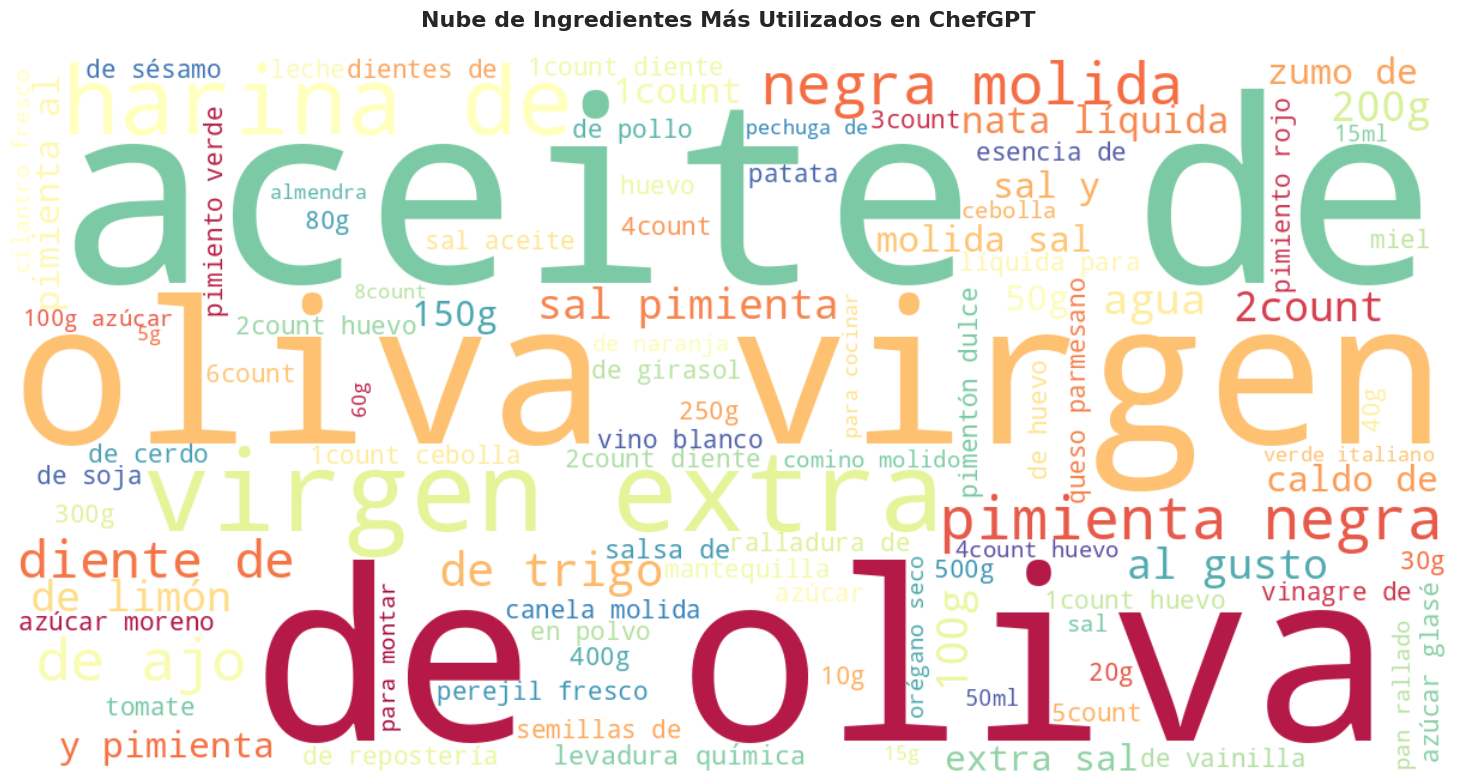


Top 20 ingredientes más comunes:
Sal                             646
Aceite de oliva virgen extra    392
Pimienta negra molida           371
Sal y pimienta al gusto         144
1count Huevo                    107
Perejil fresco                   97
1count Cebolla                   88
1count Diente de ajo             86
2count Huevo                     79
Pimentón dulce                   59
2count Diente de ajo             58
Canela molida                    57
Agua                             54
1 Cebolla                        54
Orégano seco                     49
Cilantro fresco                  48
Azúcar                           47
Harina de trigo                  47
2g Sal                           45
50g Mantequilla                  42
Name: count, dtype: int64


In [59]:
from wordcloud import WordCloud

# Reunir todos los ingredientes normalizados
todos_ingredientes = " ".join(df['ingredientes'].apply(
    lambda x: " ".join([ing.lower() for ing in x]) if isinstance(x, list) else str(x)
))

# Crear nube de palabras
wordcloud = WordCloud(
    width=1200, 
    height=600,
    background_color='white',
    colormap='Spectral',
    max_words=100
).generate(todos_ingredientes)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Ingredientes Más Utilizados en ChefGPT', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Estadísticas de ingredientes más comunes
ingredient_freq = pd.Series([ing for ing_list in df['ingredientes'] if isinstance(ing_list, list) 
                              for ing in ing_list]).value_counts().head(20)
print("\nTop 20 ingredientes más comunes:")
print(ingredient_freq)

**Comentarios cualitativos (nube de palabras)**

- La nube muestra que ingredientes básicos y de despensa dominan el corpus, lo que es esperable pero puede enmascarar ingredientes distintivos o específicos de recetas regionales.
- Este patrón sugiere priorizar la normalización (unificar variantes y eliminar metadatos entre paréntesis) y considerar eliminar o reducir el peso de términos muy frecuentes (p. ej. "sal", "agua", "aceite") si el objetivo es resaltar ingredientes característicos.
- La nube confirma coherencia temática del corpus y es útil para priorizar qué términos normalizar primero y para definir diccionarios de sinónimos.

## Proyección Semántica

Cargando modelo de embeddings multilingüe...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings para 100 recetas...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Aplicando T-SNE (reducción a 2D)...


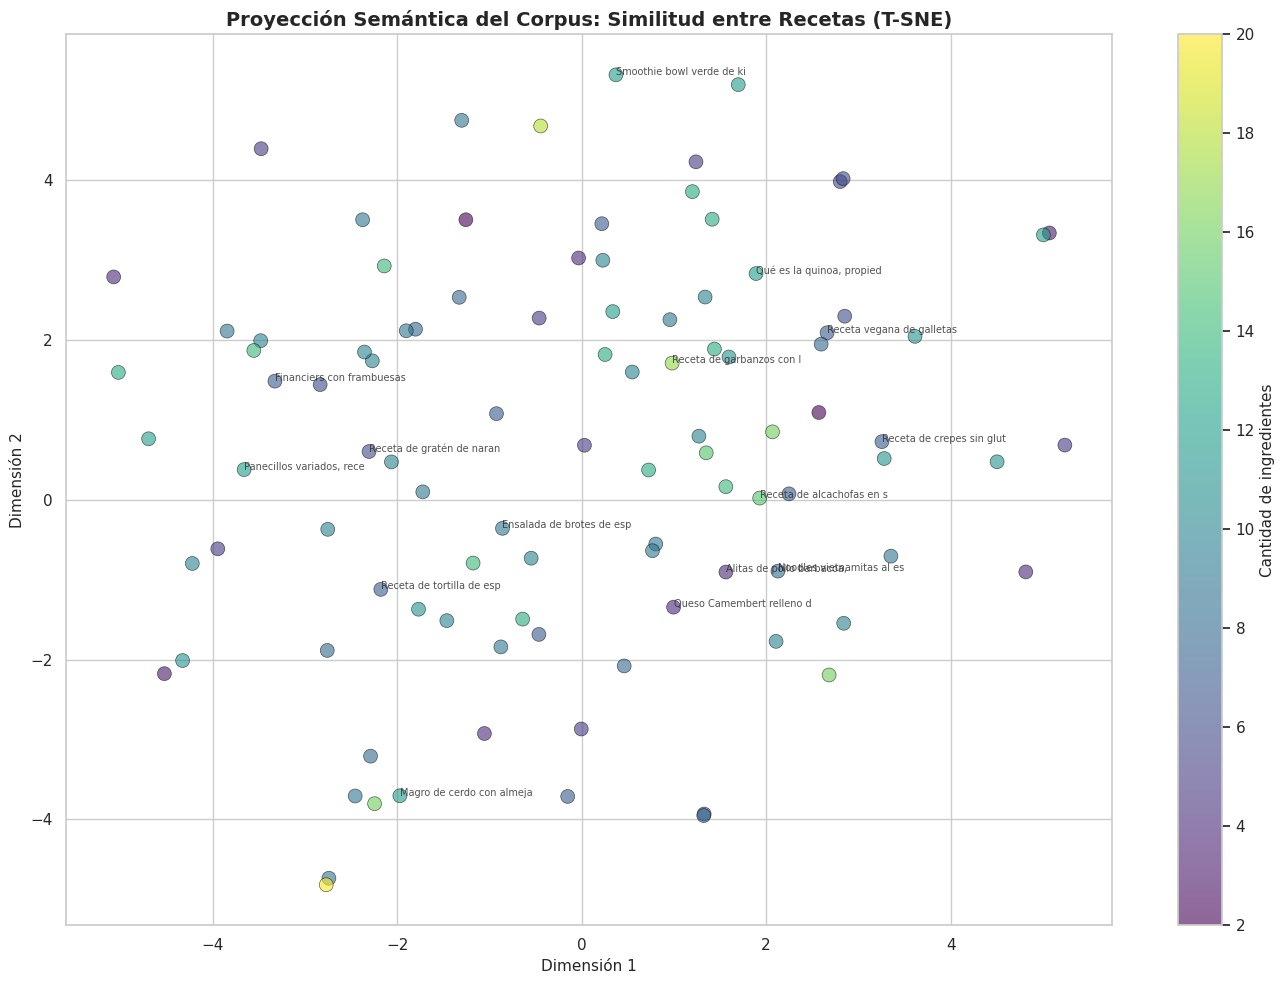


Interpretación: Recetas cercanas en el espacio son semánticamente similares.


In [60]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

# Crear texto_limpio si aún no existe
if 'texto_limpio' not in df.columns:
    df['texto_limpio'] = df['instrucciones'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else str(x)
    )

print("Cargando modelo de embeddings multilingüe...")
model_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Muestrear 100 recetas para visualización
df_sample_viz = df.sample(n=min(100, len(df)), random_state=42).copy()

print(f"Generando embeddings para {len(df_sample_viz)} recetas...")
embeddings = model_embeddings.encode(df_sample_viz['texto_limpio'].tolist(), show_progress_bar=True)

print("Aplicando T-SNE (reducción a 2D)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_sample_viz)-1))
proyeccion_2d = tsne.fit_transform(embeddings)

# Colorear por número de ingredientes (para insight adicional)
colors = df_sample_viz['ingredientes_count_real'].values

plt.figure(figsize=(14, 10))
scatter = plt.scatter(proyeccion_2d[:, 0], proyeccion_2d[:, 1], 
                      c=colors, cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Anotar algunos títulos
for i in range(min(15, len(df_sample_viz))):
    titulo_short = df_sample_viz['titulo'].iloc[i][:25]
    plt.annotate(titulo_short, 
                (proyeccion_2d[i, 0], proyeccion_2d[i, 1]), 
                fontsize=7, alpha=0.8)

plt.colorbar(scatter, label='Cantidad de ingredientes')
plt.title('Proyección Semántica del Corpus: Similitud entre Recetas (T-SNE)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Dimensión 1', fontsize=11)
plt.ylabel('Dimensión 2', fontsize=11)
plt.tight_layout()
plt.show()

print("\nInterpretación: Recetas cercanas en el espacio son semánticamente similares.")

**Comentarios cualitativos (T-SNE y embeddings)**

- La proyección sugiere clusters semánticos coherentes: recetas cercanas comparten ingredientes, técnicas o intenciones culinarias, lo que valida la utilidad de embeddings para agrupar y muestrear el corpus.
- Colorear por `ingredientes_count_real` muestra separación parcial entre recetas sencillas y complejas; las recetas con muchos ingredientes tienden (aunque muy levemente) a agruparse, indicando una señal de complejidad culinaria en el espacio latente.
- Precauciones: T‑SNE es estocástico y sensible a parámetros; repetir con distintas semillas y probar UMAP puede dar una visión más robusta. Además, la calidad de las agrupaciones depende fuertemente de la limpieza de texto (normalizar ingredientes y remover ruido mejora la separación).

## Análisis de Bigramas: Técnicas y Conceptos Culinarios

/tmp/ipykernel_1000/3510299704.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette="YlOrRd_r")


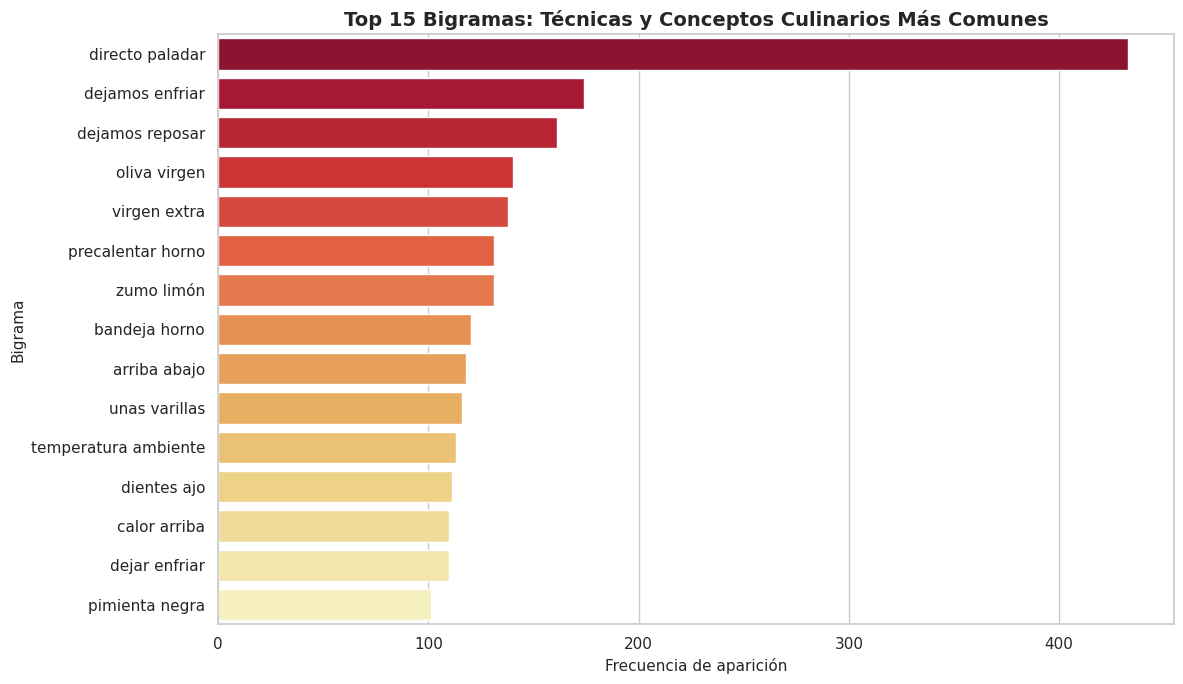


Top 15 bigramas encontrados:
  directo paladar: 433
  dejamos enfriar: 174
  dejamos reposar: 161
  oliva virgen: 140
  virgen extra: 138
  precalentar horno: 131
  zumo limón: 131
  bandeja horno: 120
  arriba abajo: 118
  unas varillas: 116
  temperatura ambiente: 113
  dientes ajo: 111
  calor arriba: 110
  dejar enfriar: 110
  pimienta negra: 101


In [61]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

# Descargar stopwords español
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Definir stopwords amplificados con términos culinarios genéricos
stop_words_sp = set(stopwords.words('spanish')).union({
    'luego', 'después', 'cada', 'hacer', 'puedes', 'si', 'tan', 'añadir',
    'poner', 'bien', 'minutos', 'fuego', 'aceite', 'sal', 'agua', 'vez',
    'parte', 'cosa', 'momento', 'forma', 'tiempo', 'poco', 'todo'
})

# Limpiar instrucciones para análisis de NLP
if 'texto_limpio' not in df.columns:
    df['texto_limpio'] = df['instrucciones'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else str(x)
    )

# Extraer top bigramas
def get_top_ngram(corpus, n=2, top_n=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=list(stop_words_sp), max_features=200).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]

top_bigrams = get_top_ngram(df['texto_limpio'], n=2, top_n=15)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(12, 7))
sns.barplot(x=y, y=x, palette="YlOrRd_r")
plt.title('Top 15 Bigramas: Técnicas y Conceptos Culinarios Más Comunes', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia de aparición', fontsize=11)
plt.ylabel('Bigrama', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nTop 15 bigramas encontrados:")
for bigram, count in top_bigrams:
    print(f"  {bigram}: {count}")

**Comentarios cualitativos**

Análisis y recomendaciones:
- Dominio procedimental: muchos bigramas son instrucciones o pasos (`dejamos enfriar`, `precalentar horno`, `arriba abajo`). El corpus enfatiza la secuencia de acciones; extraer etiquetas de técnica (`hornear`, `enfriar`, `batir`) ayudará a clasificar recetas por proceso.
- Redundancia y variante léxica: aparecen variantes cercanas (`dejamos enfriar` vs `dejar enfriar`) y duplicados funcionales. Aplicar lematización/normalización de formas verbales y agrupar variantes reduce ruido y consolida señales.
- Ingredientes y medidas frecuentes: `oliva virgen` / `virgen extra`, `zumo limón`, `dientes ajo`, `pimienta negra` muestran ingredientes clave. Mapear sinónimos y formas parciales (ej. juntar `oliva virgen` + `virgen extra` → `aceite de oliva`) mejora búsquedas por ingrediente y reduce sparsity en el vocabulario.
- Utensilios y condiciones: bigramas como `unas varillas` y `temperatura ambiente` aportan metadatos procedimentales (herramientas, condiciones) útiles para prompts y para generar instrucciones condicionadas.
- Señal vs ruido: `directo paladar` es muy frecuente —revisar contextos para decidir si es una locución informativa o tokenización ruidosa; si es ruido, considerarlo en la lista de stopphrases.

## Implicaciones para el RAG (resumen ejecutivo)

Este EDA no solo describe el corpus; orienta decisiones de limpieza, chunking y metadatos. El corpus es reutilizable, pero requiere normalizaciones antes de construir el índice.

### Hallazgos clave y acciones sugeridas

| **Aspecto** | **Hallazgo** | **Acción sugerida** |
|---|---|---|
| **Estructura** | 7 campos principales con mezcla de texto y listas | Mantener esquema y crear metadatos derivados normalizados |
| **Tiempo** | Texto libre que se parsea a minutos | Normalizar a `tiempo_min` y usar como filtro |
| **Porciones** | Tipos mixtos y casos atípicos | Convertir a `porciones_num`, marcar no parseables |
| **Ingredientes** | Formato heterogéneo con unidades variadas | Separar cantidad, unidad e ingrediente; normalizar sinónimos |
| **Instrucciones** | Recetas muy largas y procedimentales | Chunking por pasos/frases; conservar orden y solapamiento leve |
| **Autores** | Concentración en pocas firmas | Usar como metadato opcional; evitar sesgo en ranking |
| **Calidad** | Discrepancias en `n_ingredientes` y duplicados | Auditar y excluir o corregir antes de indexar |

### Implicaciones directas para el pipeline

1. **Metadata limpia**: indexar `tiempo_min`, `porciones_num`, `ingredientes_count_real` y `n_ingredientes` como numéricos para filtros y reranking.
2. **Normalización de ingredientes**: crear un vocabulario canónico (ej. `aceite de oliva`), pero conservar la forma original para respuestas.
3. **Stopphrases y variantes**: filtrar frases de marca y unificar variantes verbales para reducir ruido en embeddings y n-grams.
4. **Chunking inteligente**: segmentar instrucciones por pasos; adjuntar `titulo` e ingredientes en metadatos para preservar contexto.
5. **Embeddings adecuados**: usar modelos multilingües y asegurar `texto_limpio` consistente para el índice vectorial.
6. **Control de calidad previo**: retirar recetas inconsistentes o casi duplicadas para evitar respuestas repetidas.

### Conclusión

El corpus es **apto para RAG** con los ajustes anteriores. La limpieza de metadatos, la normalización de ingredientes y el chunking procedimental son las palancas con mayor impacto en la recuperación y la calidad de las respuestas.